In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import optuna
import pandas as pd
import plotnine as p9

In [2]:
l = list()
for approach in ['Fine-tuning', 'Fine-tuning-Truncated', 'Chefer_importance', 'Sliding_windows', 'Attention_distillation']:
  for dataset in ['IMDb-1k', 'Ohsumed', 'R8', 'SST-2']: # 'IMDb'
    for binding in ['', '-unbound']:
      study_name = f'{dataset}-{approach}{binding}'
      if not os.path.exists(f'../../optuna_studies/{study_name}.db'):
        print(f'Skipping {study_name}...')
        continue
      study = optuna.load_study(
        study_name = study_name,
        storage = f'sqlite:///../../optuna_studies/{study_name}.db'
      )
      trials_df = study.trials_dataframe()
      trials_df = trials_df[(trials_df['state'] == 'COMPLETE') & (trials_df['value'] >= 0.0)][['number', 'value']] \
        .assign(
          approach = approach,
          dataset = dataset,
          binding = binding
        )
      l.append(trials_df)
trials_df = pd.concat(l, ignore_index = True)

In [3]:
trials_df['value'] = trials_df['value'] * 100
trials_df['approach'] = trials_df['approach'].replace({
  'Fine-tuning' : 'Chunk-based\nFine-tuning', #'FT (Chunks)',
  'Fine-tuning-Truncated' : 'Fine-tuning', #'FT',
  'Chefer_importance' : 'Chefer\nImportance', #'CI',
  'Sliding_windows' : 'Sliding\nWindows', #'SW',
  'Attention_distillation' : 'Attention\nDistillation'#'AD'
})
trials_df['approach'] = pd.Categorical(trials_df['approach'], categories = ['Fine-tuning', 'Chunk-based\nFine-tuning', 'Sliding\nWindows', 'Attention\nDistillation', 'Chefer\nImportance'], ordered = True) # categories = ['FT', 'TFT', 'SW', 'AD', 'CI']
trials_df['binding'] = trials_df['binding'].replace({
  '' : 'Discrete',
  '-unbound' : 'Continuous',
})
trials_df['binding'] = pd.Categorical(trials_df['binding'], categories = ['Discrete', 'Continuous'], ordered = True)

In [4]:
# trials_df.groupby(by = ['dataset', 'approach', 'binding']).size()

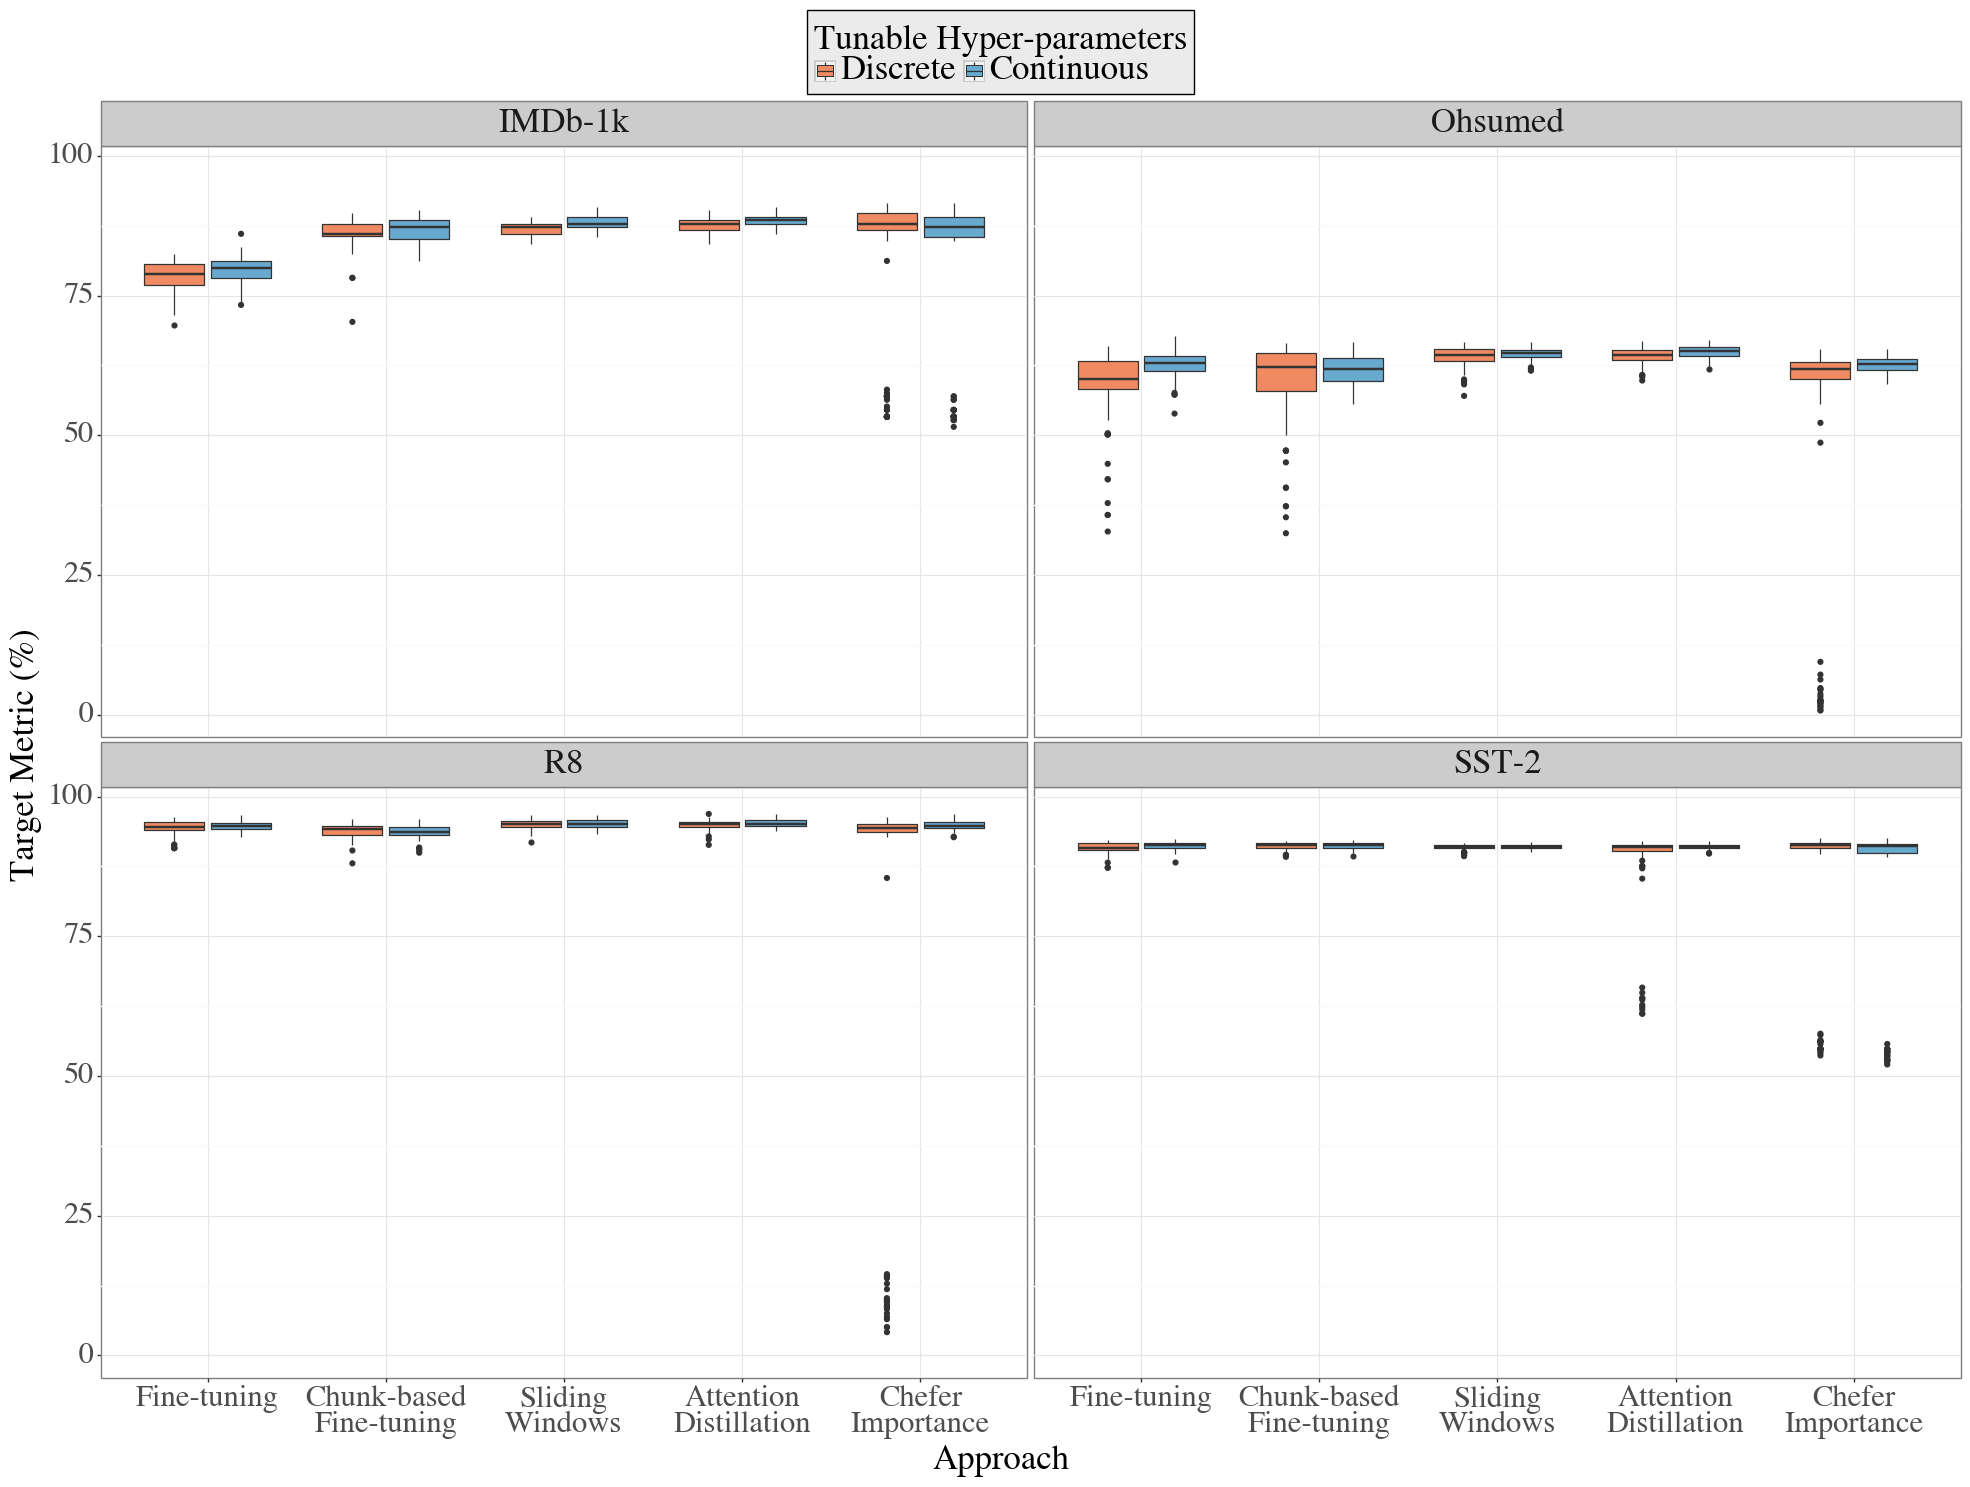

<ggplot: (334945437)>

In [5]:
p9.ggplot(
    trials_df,
    p9.aes(x = 'approach', y = 'value', fill = 'binding')
  ) + \
    p9.geom_boxplot() + \
    p9.xlab('Approach') + \
    p9.ylab('Target Metric (%)') + \
    p9.labs(fill = 'Tunable Hyper-parameters') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [6]:
aggregated_trials_df = trials_df.groupby(by = ['dataset', 'binding', 'approach']).agg({'value' : ['mean', 'std']}).reset_index()
aggregated_trials_df.columns = aggregated_trials_df.columns.map('_'.join).str.strip('_')
aggregated_trials_df['label'] = aggregated_trials_df['value_mean'].round(2).astype(str) + ' ± ' + aggregated_trials_df['value_std'].round(2).astype(str)

In [7]:
plot = p9.ggplot(
    aggregated_trials_df,
    p9.aes(x = 'approach', y = 'value_mean', fill = 'binding')
  ) + \
    p9.geom_bar(stat = 'identity', position = p9.position_dodge2(), colour = '#000000') + \
    p9.geom_errorbar(p9.aes(ymin = 'value_mean - value_std', ymax = 'value_mean + value_std'), position = p9.position_dodge(width = .9), width = .4, size = .85) + \
    p9.geom_text(p9.aes(y = 'value_mean - value_std - 2.5', label = 'label'), position = p9.position_dodge2(width = .9), size = 20, angle = 90, va = 'top') + \
    p9.xlab('Approach') + \
    p9.ylab('Target Metric (%)') + \
    p9.labs(fill = 'Tunable Hyper-parameters') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2, scales = 'free_y') + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
      subplots_adjust = {
        'wspace' : 0.075
      }
    )

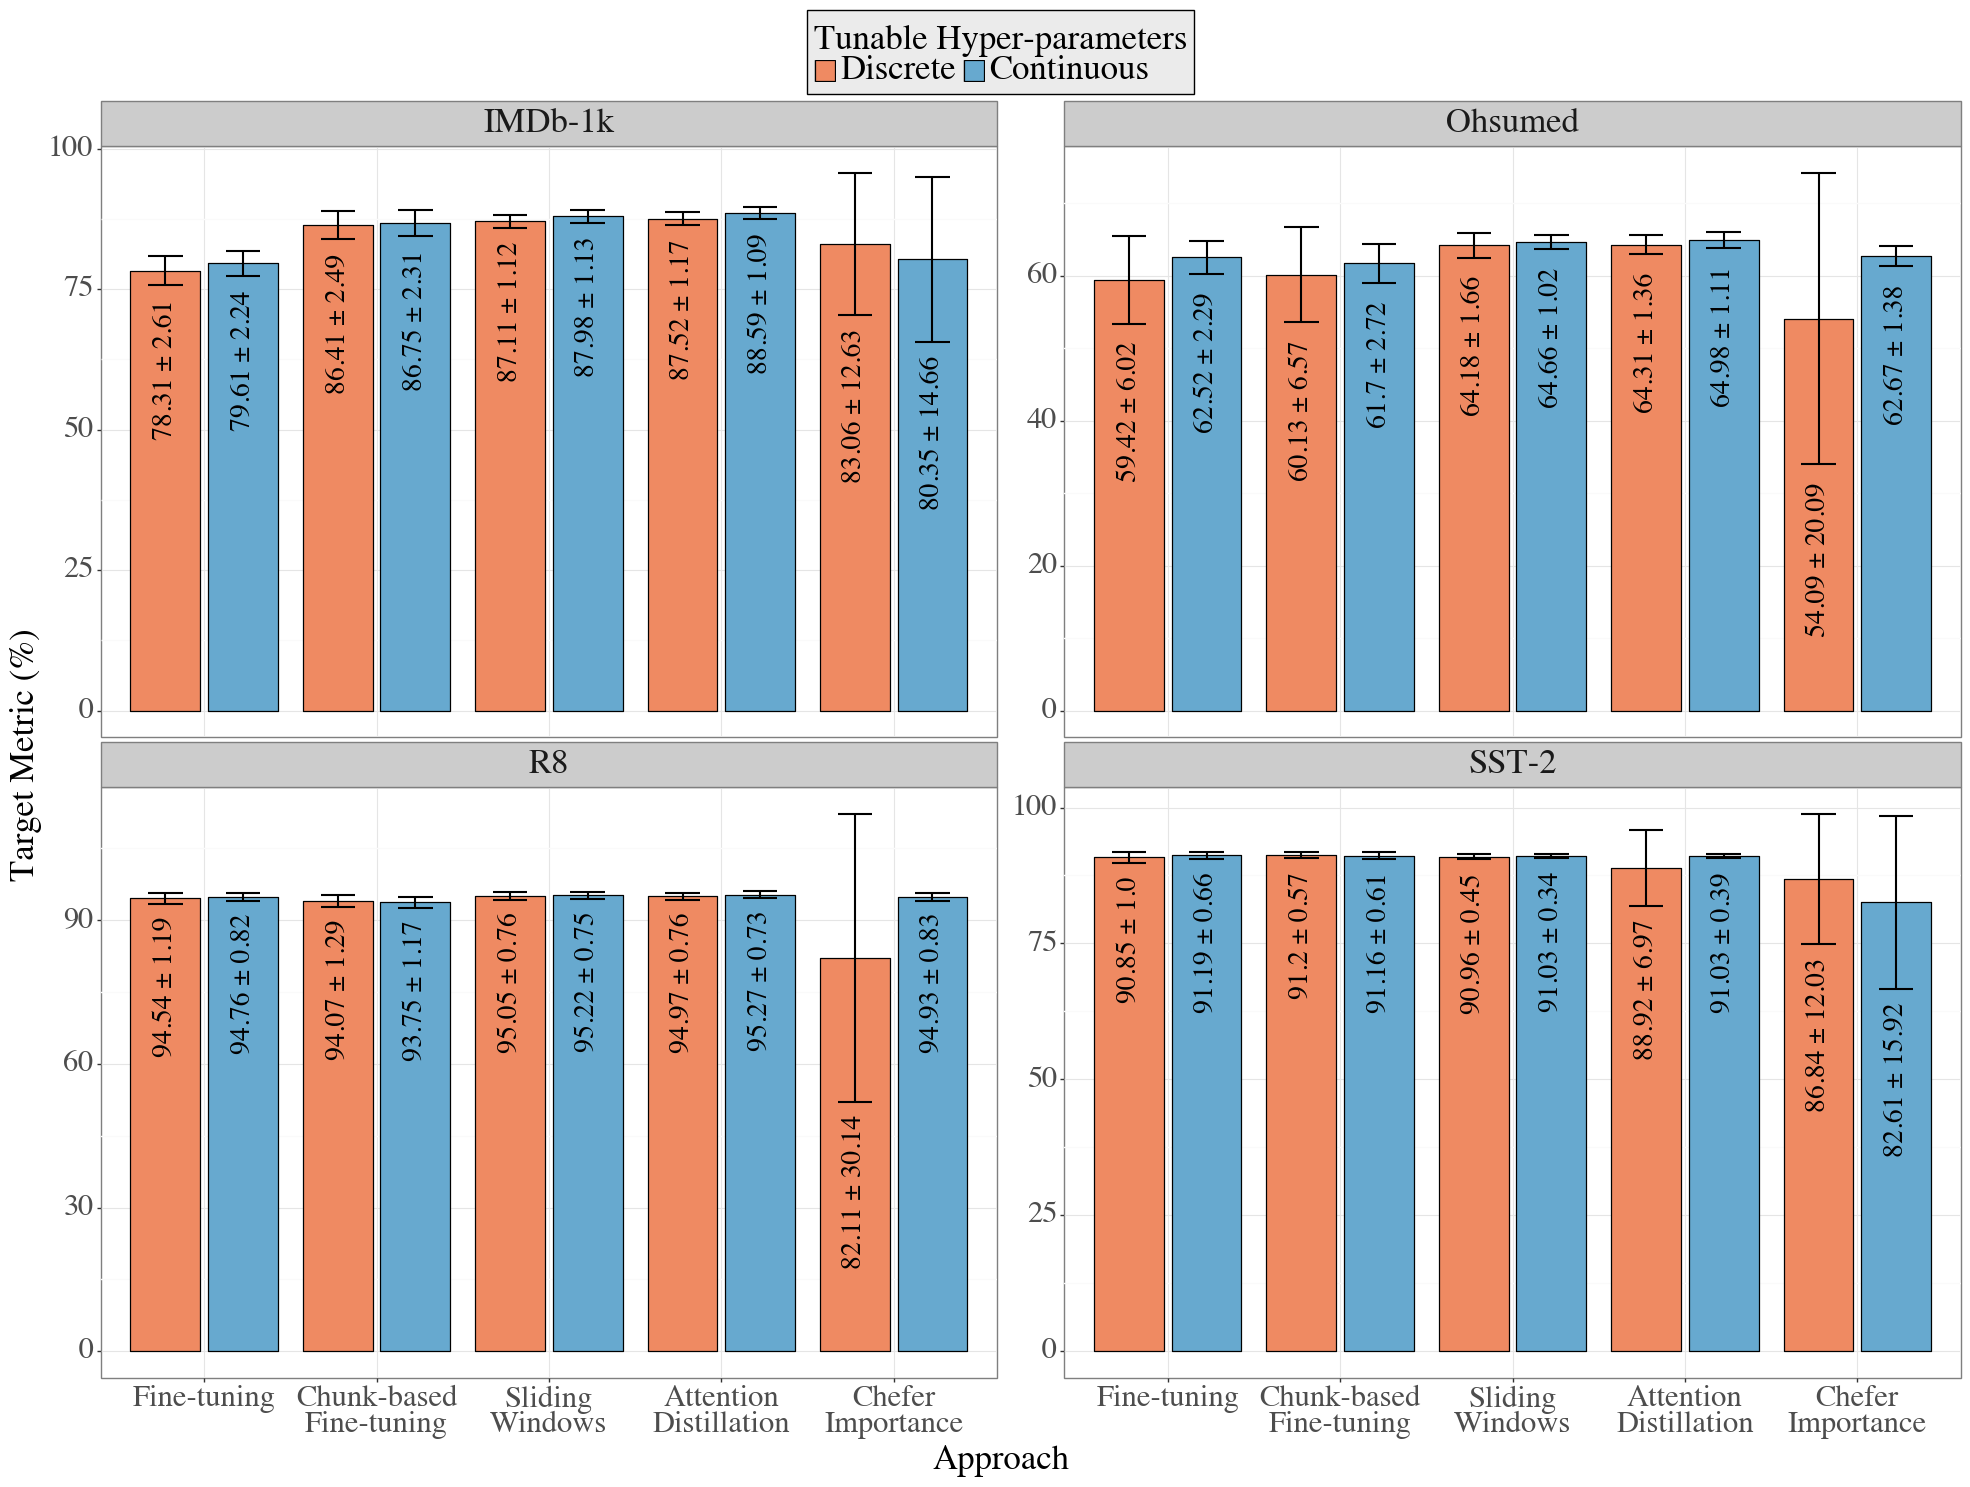

<ggplot: (335365532)>

In [8]:
plot

In [ ]:
# plot.save(filename = '../figures/validation_performance.png', dpi = 300)

In [10]:
aggregated_trials_df = trials_df.groupby(by = ['dataset', 'binding', 'approach']).agg(median = ('value', 'median'), q1 = ('value', lambda x : x.quantile(0.25)), q3 = ('value', lambda x : x.quantile(0.75))).reset_index()
aggregated_trials_df['label'] = aggregated_trials_df['median'].round(2).astype(str) + ' [' + aggregated_trials_df['q1'].round(2).astype(str) + ', ' + aggregated_trials_df['q3'].round(2).astype(str) + ']'

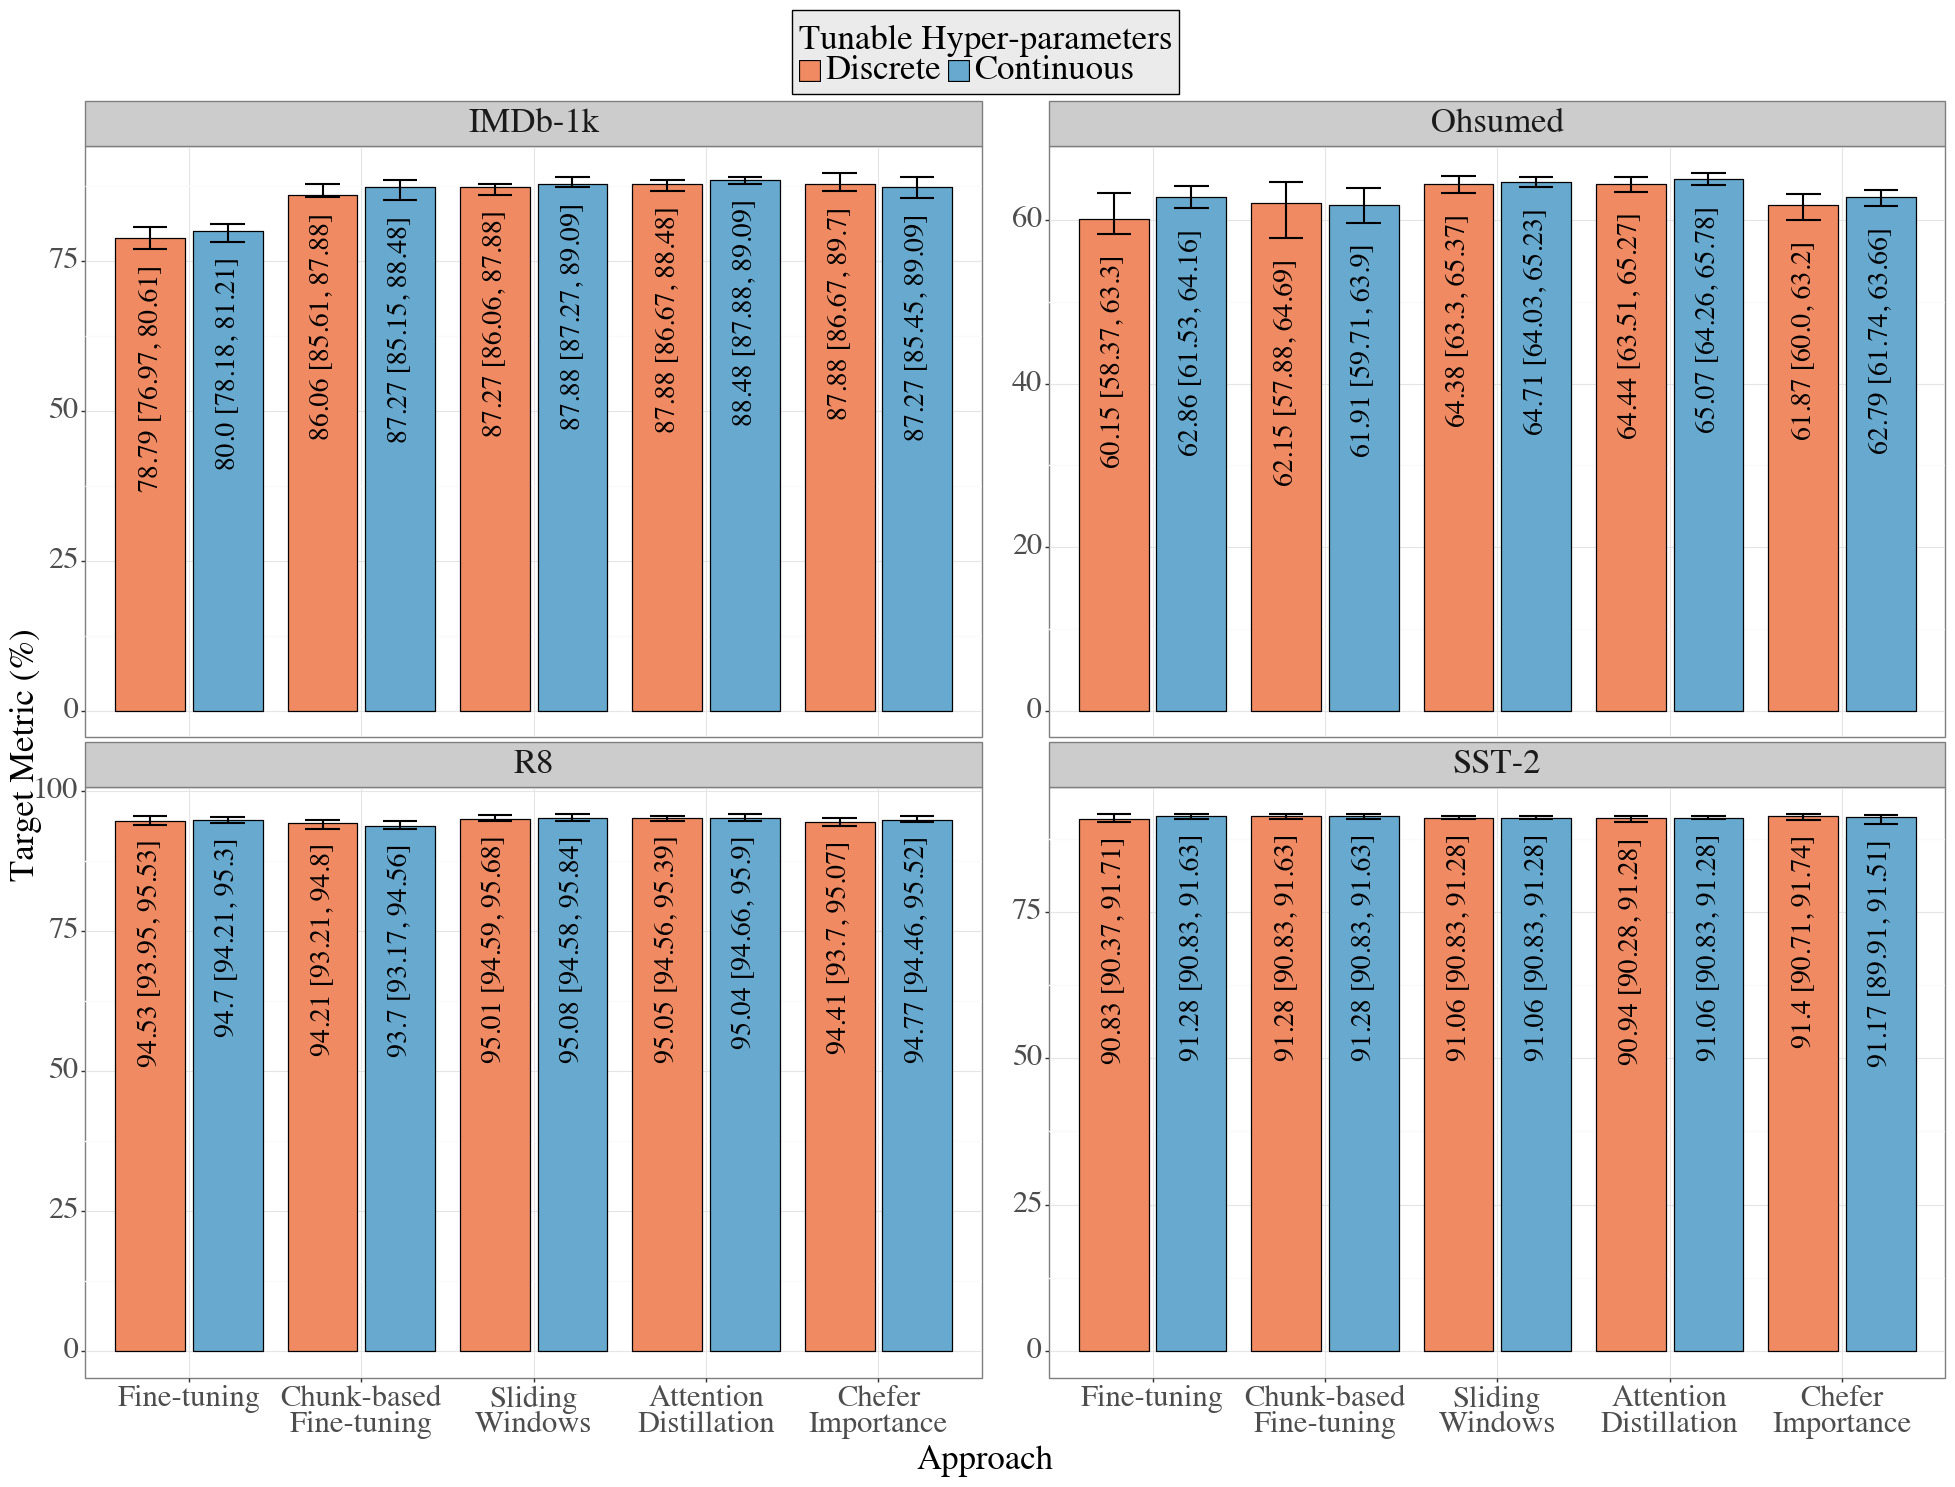

<ggplot: (336188684)>

In [ ]:
plot = p9.ggplot(
    aggregated_trials_df,
    p9.aes(x = 'approach', y = 'median', fill = 'binding')
  ) + \
    p9.geom_bar(stat = 'identity', position = p9.position_dodge2(), colour = '#000000') + \
    p9.geom_errorbar(p9.aes(ymin = 'q1', ymax = 'q3'), position = p9.position_dodge(width = .9), width = .4, size = .85) + \
    p9.geom_text(p9.aes(y = 'q1 - 2.5', label = 'label'), position = p9.position_dodge2(width = .9), size = 20, angle = 90, va = 'top') + \
    p9.xlab('Approach') + \
    p9.ylab('Target Metric (%)') + \
    p9.labs(fill = 'Tunable Hyper-parameters') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2, scales = 'free_y') + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
      subplots_adjust = {
        'wspace' : 0.075
      }
    )

In [ ]:
plot

In [ ]:
# plot.save(filename = '../figures/validation_performance_quartiles.png', dpi = 300)

In [14]:
trials_df

,number,value,approach,dataset,binding
0,0,83.636364,Chunk-based\nFine-tuning,IMDb-1k,Discrete
1,1,87.878788,Chunk-based\nFine-tuning,IMDb-1k,Discrete
2,2,86.666667,Chunk-based\nFine-tuning,IMDb-1k,Discrete
3,3,85.454545,Chunk-based\nFine-tuning,IMDb-1k,Discrete
4,4,86.060606,Chunk-based\nFine-tuning,IMDb-1k,Discrete
...,...,...,...,...,...
5055,107,90.940367,Attention\nDistillation,SST-2,Continuous
5056,108,91.513761,Attention\nDistillation,SST-2,Continuous
5057,109,90.825688,Attention\nDistillation,SST-2,Continuous
5058,110,90.825688,Attention\nDistillation,SST-2,Continuous


In [17]:
def find_outliers(group):
  q1 = group['value'].quantile(0.25)
  q3 = group['value'].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  return group[(group['value'] < lower) | (group['value'] > upper)]
trials_df.groupby(['dataset', 'binding', 'approach'], group_keys = False) \
  .apply(find_outliers)

,number,value,approach,dataset,binding
1048,37,69.696970,Fine-tuning,IMDb-1k,Discrete
34,34,78.181818,Chunk-based\nFine-tuning,IMDb-1k,Discrete
71,87,78.181818,Chunk-based\nFine-tuning,IMDb-1k,Discrete
96,118,70.303030,Chunk-based\nFine-tuning,IMDb-1k,Discrete
2026,5,53.333333,Chefer\nImportance,IMDb-1k,Discrete
...,...,...,...,...,...
2993,60,53.669725,Chefer\nImportance,SST-2,Continuous
2996,63,54.816514,Chefer\nImportance,SST-2,Continuous
2997,64,52.981651,Chefer\nImportance,SST-2,Continuous
3008,75,54.357798,Chefer\nImportance,SST-2,Continuous


In [20]:
method_outliers = trials_df[trials_df['approach'] == 'Chefer\nImportance'].groupby(['dataset', 'binding', 'approach'], group_keys = False) \
  .apply(find_outliers)
method_outliers

,number,value,approach,dataset,binding
2026,5,53.333333,Chefer\nImportance,IMDb-1k,Discrete
2029,8,56.969697,Chefer\nImportance,IMDb-1k,Discrete
2031,10,57.575758,Chefer\nImportance,IMDb-1k,Discrete
2032,11,53.333333,Chefer\nImportance,IMDb-1k,Discrete
2033,13,56.969697,Chefer\nImportance,IMDb-1k,Discrete
...,...,...,...,...,...
2993,60,53.669725,Chefer\nImportance,SST-2,Continuous
2996,63,54.816514,Chefer\nImportance,SST-2,Continuous
2997,64,52.981651,Chefer\nImportance,SST-2,Continuous
3008,75,54.357798,Chefer\nImportance,SST-2,Continuous


In [21]:
method_outliers.groupby(by = ['dataset']).size()

dataset
IMDb-1k    50
Ohsumed    22
R8         25
SST-2      43
dtype: int64

In [22]:
l = list()
for approach in ['Chefer_importance']:
  for dataset in ['IMDb-1k', 'Ohsumed', 'R8', 'SST-2']: # 'IMDb'
    for binding in ['', '-unbound']:
      study_name = f'{dataset}-{approach}{binding}'
      if not os.path.exists(f'../../optuna_studies/{study_name}.db'):
        print(f'Skipping {study_name}...')
        continue
      study = optuna.load_study(
        study_name = study_name,
        storage = f'sqlite:///../../optuna_studies/{study_name}.db'
      )
      trials_df = study.trials_dataframe()
      trials_df = trials_df[(trials_df['state'] == 'COMPLETE') & (trials_df['value'] >= 0.0)] \
        .assign(
          approach = approach,
          dataset = dataset,
          binding = binding
        )
      l.append(trials_df)
all_trials_df = pd.concat(l, ignore_index = True)

In [23]:
all_trials_df['value'] = all_trials_df['value'] * 100
all_trials_df['approach'] = all_trials_df['approach'].replace({
  'Fine-tuning' : 'Chunk-based\nFine-tuning', #'FT (Chunks)',
  'Fine-tuning-Truncated' : 'Fine-tuning', #'FT',
  'Chefer_importance' : 'Chefer\nImportance', #'CI',
  'Sliding_windows' : 'Sliding\nWindows', #'SW',
  'Attention_distillation' : 'Attention\nDistillation'#'AD'
})
all_trials_df['approach'] = pd.Categorical(all_trials_df['approach'], categories = ['Fine-tuning', 'Chunk-based\nFine-tuning', 'Sliding\nWindows', 'Attention\nDistillation', 'Chefer\nImportance'], ordered = True) # categories = ['FT', 'TFT', 'SW', 'AD', 'CI']
all_trials_df['binding'] = all_trials_df['binding'].replace({
  '' : 'Discrete',
  '-unbound' : 'Continuous',
})
all_trials_df['binding'] = pd.Categorical(all_trials_df['binding'], categories = ['Discrete', 'Continuous'], ordered = True)

In [38]:
method_outliers = method_outliers.merge(all_trials_df[['number', 'approach', 'dataset', 'binding'] + list(all_trials_df.filter(regex = r'^params_').columns)], how = 'left', on = ['number', 'approach', 'dataset', 'binding'])

In [46]:
method_outliers.describe()

,number,value,params_attention_heads,params_batch_size,params_dropout_rate,params_edge_threshold,params_hidden_dimension,params_learning_rate,params_node_threshold,params_number_of_hidden_layers,params_weight_decay
count,140.000000,140.000000,140.00000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,51.514286,41.118523,3.45000,54.400000,0.261369,0.738857,78.950000,0.000386,0.773929,0.064286,0.000198
std,43.802448,23.450602,2.38498,32.117769,0.090031,0.135854,37.636528,0.000401,0.140378,0.322104,0.000324
min,3.000000,0.759859,1.00000,16.000000,0.100000,0.500000,32.000000,0.000010,0.500000,0.000000,0.000001
25%,16.000000,11.453667,1.75000,32.000000,0.200000,0.600000,43.500000,0.000034,0.600000,0.000000,0.000004
50%,40.000000,53.333333,2.00000,48.000000,0.280504,0.740000,64.000000,0.000295,0.800000,0.000000,0.000092
75%,77.250000,54.816514,6.00000,64.000000,0.300000,0.862500,125.250000,0.001000,0.902500,0.000000,0.000108
max,194.000000,92.833878,8.00000,128.000000,0.400000,0.950000,128.000000,0.001000,0.950000,2.000000,0.001000


In [47]:
method_outliers['params_number_of_hidden_layers'].value_counts()

params_number_of_hidden_layers
0    134
1      3
2      3
Name: count, dtype: int64

In [48]:
all_trials_df['params_number_of_hidden_layers'].value_counts()

params_number_of_hidden_layers
2    441
1    437
0    134
Name: count, dtype: int64

In [44]:
all_trials_df[all_trials_df['dataset'] == 'SST-2'][['value', 'params_learning_rate', 'params_node_threshold', 'params_edge_threshold', 'params_number_of_hidden_layers']]

,value,params_learning_rate,params_node_threshold,params_edge_threshold,params_number_of_hidden_layers
759,91.055046,0.001000,0.60,0.80,1
760,91.399083,0.001000,0.60,0.50,2
761,91.284404,0.001000,0.50,0.90,2
762,91.055046,0.000300,0.50,0.50,1
763,90.711009,0.000010,0.90,0.95,2
...,...,...,...,...,...
1007,91.857798,0.000493,0.93,0.86,1
1008,91.399083,0.000208,0.94,0.57,1
1009,91.628440,0.000123,0.94,0.85,1
1010,91.743119,0.000112,0.94,0.81,1


In [39]:
method_outliers[method_outliers['dataset'] == 'SST-2']

,number,value,approach,dataset,binding,params_attention_heads,params_batch_size,params_dropout_rate,params_edge_threshold,params_hidden_dimension,params_learning_rate,params_node_threshold,params_number_of_hidden_layers,params_weight_decay
97,5,54.816514,Chefer\nImportance,SST-2,Discrete,6,64,0.200000,0.90,64,0.000010,0.70,0,0.000001
98,8,56.192661,Chefer\nImportance,SST-2,Discrete,6,32,0.200000,0.95,32,0.001000,0.70,0,0.000100
99,10,56.422018,Chefer\nImportance,SST-2,Discrete,4,16,0.400000,0.60,64,0.000010,0.60,0,0.000100
100,11,54.816514,Chefer\nImportance,SST-2,Discrete,2,64,0.200000,0.90,32,0.000300,0.70,0,0.000001
101,13,55.733945,Chefer\nImportance,SST-2,Discrete,1,32,0.200000,0.60,64,0.000300,0.60,0,0.000010
102,16,54.357798,Chefer\nImportance,SST-2,Discrete,6,128,0.300000,0.80,32,0.001000,0.70,0,0.000100
103,21,56.192661,Chefer\nImportance,SST-2,Discrete,2,32,0.200000,0.70,64,0.001000,0.95,0,0.001000
104,32,57.568807,Chefer\nImportance,SST-2,Discrete,8,16,0.300000,0.70,128,0.000300,0.80,0,0.000100
105,33,53.669725,Chefer\nImportance,SST-2,Discrete,4,128,0.400000,0.80,64,0.000300,0.90,0,0.000100
106,34,56.192661,Chefer\nImportance,SST-2,Discrete,1,32,0.400000,0.80,64,0.001000,0.60,0,0.001000


In [45]:
all_trials_df[all_trials_df['dataset'] == 'IMDb-1k'][['value', 'params_learning_rate', 'params_node_threshold', 'params_edge_threshold', 'params_number_of_hidden_layers']]

,value,params_learning_rate,params_node_threshold,params_edge_threshold,params_number_of_hidden_layers
0,86.666667,0.001000,0.50,0.90,2
1,86.060606,0.000010,0.90,0.95,2
2,53.333333,0.000010,0.70,0.90,0
3,87.272727,0.000010,0.80,0.80,2
4,86.666667,0.000100,0.60,0.80,1
...,...,...,...,...,...
248,86.666667,0.000193,0.92,0.79,2
249,89.696970,0.000011,0.95,0.70,1
250,87.272727,0.000014,0.88,0.59,2
251,88.484848,0.000022,0.95,0.67,1


In [42]:
method_outliers[method_outliers['dataset'] == 'IMDb-1k']

,number,value,approach,dataset,binding,params_attention_heads,params_batch_size,params_dropout_rate,params_edge_threshold,params_hidden_dimension,params_learning_rate,params_node_threshold,params_number_of_hidden_layers,params_weight_decay
0,5,53.333333,Chefer\nImportance,IMDb-1k,Discrete,6,64,0.200000,0.90,64,0.000010,0.70,0,0.000001
1,8,56.969697,Chefer\nImportance,IMDb-1k,Discrete,6,32,0.200000,0.95,32,0.001000,0.70,0,0.000100
2,10,57.575758,Chefer\nImportance,IMDb-1k,Discrete,4,16,0.400000,0.60,64,0.000010,0.60,0,0.000100
3,11,53.333333,Chefer\nImportance,IMDb-1k,Discrete,2,64,0.200000,0.90,32,0.000300,0.70,0,0.000001
4,13,56.969697,Chefer\nImportance,IMDb-1k,Discrete,1,32,0.200000,0.60,64,0.000300,0.60,0,0.000010
5,16,53.333333,Chefer\nImportance,IMDb-1k,Discrete,6,128,0.300000,0.80,32,0.001000,0.70,0,0.000100
6,21,53.333333,Chefer\nImportance,IMDb-1k,Discrete,2,32,0.200000,0.70,64,0.001000,0.95,0,0.001000
7,32,56.363636,Chefer\nImportance,IMDb-1k,Discrete,8,16,0.300000,0.70,128,0.000300,0.80,0,0.000100
8,33,53.333333,Chefer\nImportance,IMDb-1k,Discrete,4,128,0.400000,0.80,64,0.000300,0.90,0,0.000100
9,34,53.333333,Chefer\nImportance,IMDb-1k,Discrete,1,32,0.400000,0.80,64,0.001000,0.60,0,0.001000
